In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("statistic_store_benchmark.csv")
df['throughput'] = df['num_statistics'] / (df['duration_ms'] / 1000)

# All possible benchmark parameters (excluding benchmark, store_type, repetition, duration_ms)
ALL_PARAMS = ['num_threads', 'num_statistics', 'num_statistic_ids', 'statistic_size',
              'window_size', 'pct_access_existing', 'pct_insert', 'num_statistics_per_request', 'pct_pre_populate']

df

,benchmark,store_type,num_threads,num_statistics,num_statistic_ids,statistic_size,window_size,pct_access_existing,num_statistics_per_request,pct_insert,pct_pre_populate,random_seed,repetition,duration_ms,throughput
0,InsertStatistic,DEFAULT,1,500000,100,1024,60000,-1,-1,-1,-1,1195193710,0,5331.340,93785.052163
1,InsertStatistic,DEFAULT,1,500000,100,1024,60000,-1,-1,-1,-1,1195193710,1,5020.260,99596.435244
2,InsertStatistic,DEFAULT,1,500000,100,1024,60000,-1,-1,-1,-1,1195193710,2,5107.500,97895.252080
3,InsertStatistic,DEFAULT,4,500000,100,1024,60000,-1,-1,-1,-1,1195193710,0,5358.740,93305.515849
4,InsertStatistic,DEFAULT,4,500000,100,1024,60000,-1,-1,-1,-1,1195193710,1,5108.480,97876.472062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,InsertAndGetStatistics,SUB_STORES,16,500000,100,4096,60000,-1,10,90,10,1195193710,1,899.706,555737.096340
1508,InsertAndGetStatistics,SUB_STORES,16,500000,100,4096,60000,-1,10,90,10,1195193710,2,933.735,535483.836420
1509,InsertAndGetStatistics,SUB_STORES,16,500000,100,4096,60000,-1,100,90,10,1195193710,0,918.555,544333.219023
1510,InsertAndGetStatistics,SUB_STORES,16,500000,100,4096,60000,-1,100,90,10,1195193710,1,911.923,548291.906225


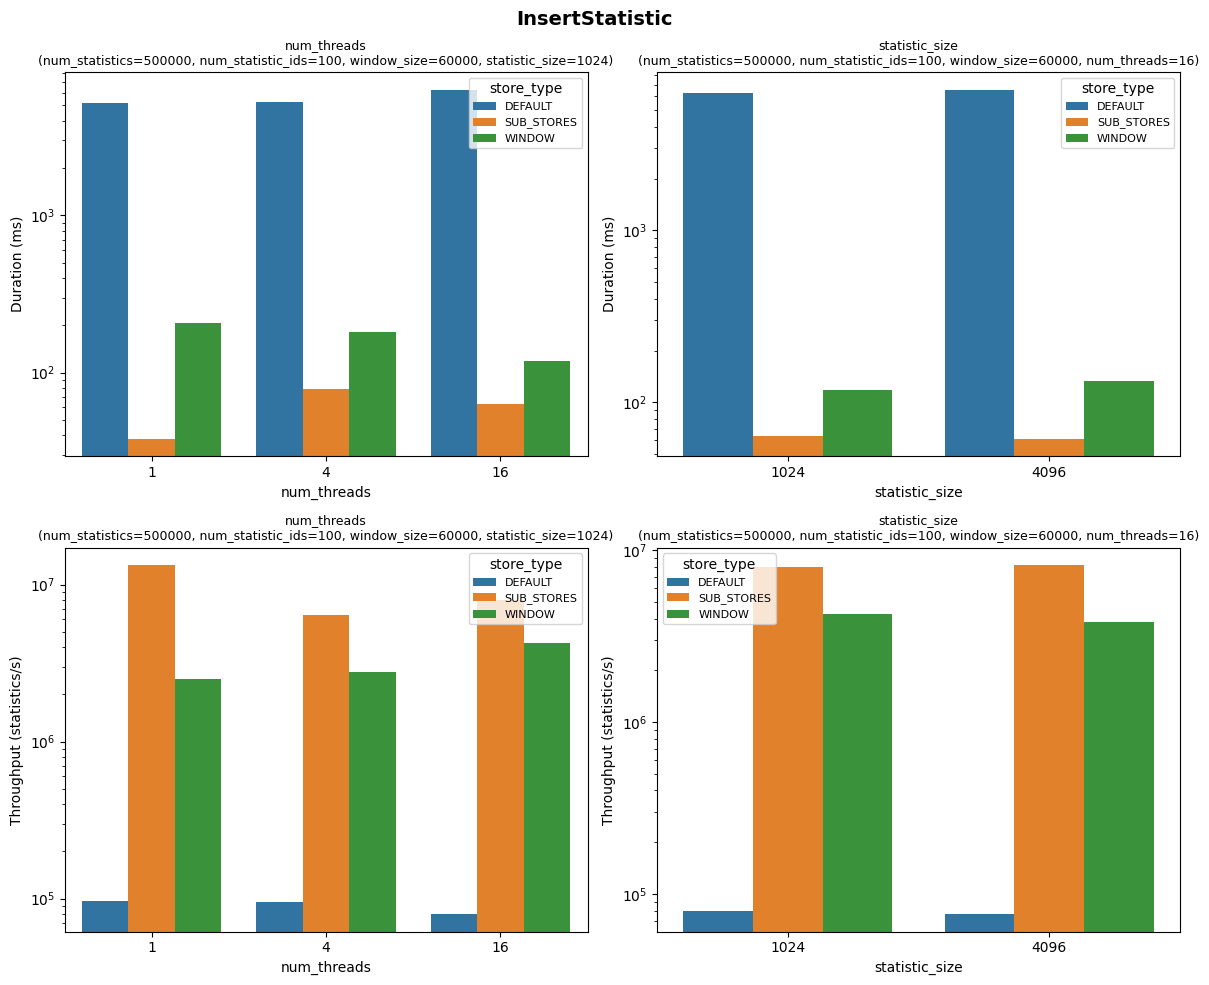

In [8]:
# InsertStatistic
# Override pinned values for 'other varying' parameters.
# By default the mode (most frequent value) is used; add entries here to override.
PIN_VALUES = {
    'num_threads': 16,
}

df_bm = df[df['benchmark'] == 'InsertStatistic'].copy()

relevant = [p for p in ALL_PARAMS if not (df_bm[p] == -1).all()]
varying = [p for p in relevant if df_bm[p].nunique() > 1]
fixed = [p for p in relevant if p not in varying]

group_cols = ['store_type'] + relevant
df_avg = df_bm.groupby(group_cols, as_index=False)[['duration_ms', 'throughput']].mean()

n = len(varying)
fig, axes = plt.subplots(2, n, figsize=(6 * n, 10), squeeze=False)

for i, param in enumerate(varying):
    other_varying = [v for v in varying if v != param]
    subset = df_avg.copy()
    for ov in other_varying:
        pin_val = PIN_VALUES.get(ov, subset[ov].mode().iloc[0])
        subset = subset[subset[ov] == pin_val]

    fixed_info = ', '.join(f'{f}={df_bm[f].iloc[0]}' for f in fixed)
    other_info = ', '.join(f'{ov}={subset[ov].iloc[0]}' for ov in other_varying)
    subtitle_parts = [s for s in [fixed_info, other_info] if s]
    subtitle = f'\n({", ".join(subtitle_parts)})' if subtitle_parts else ''

    # Duration
    ax = axes[0][i]
    sns.barplot(data=subset, x=param, y='duration_ms', hue='store_type', ax=ax)
    ax.set_yscale('log')
    ax.set_xlabel(param)
    ax.set_ylabel('Duration (ms)')
    ax.set_title(f'{param}{subtitle}', fontsize=9)
    ax.legend(title='store_type', fontsize=8)

    # Throughput
    ax = axes[1][i]
    sns.barplot(data=subset, x=param, y='throughput', hue='store_type', ax=ax)
    ax.set_yscale('log')
    ax.set_xlabel(param)
    ax.set_ylabel('Throughput (statistics/s)')
    ax.set_title(f'{param}{subtitle}', fontsize=9)
    ax.legend(title='store_type', fontsize=8)

fig.suptitle('InsertStatistic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("InsertStatistic.pdf", dpi=300, bbox_inches="tight")
plt.show()

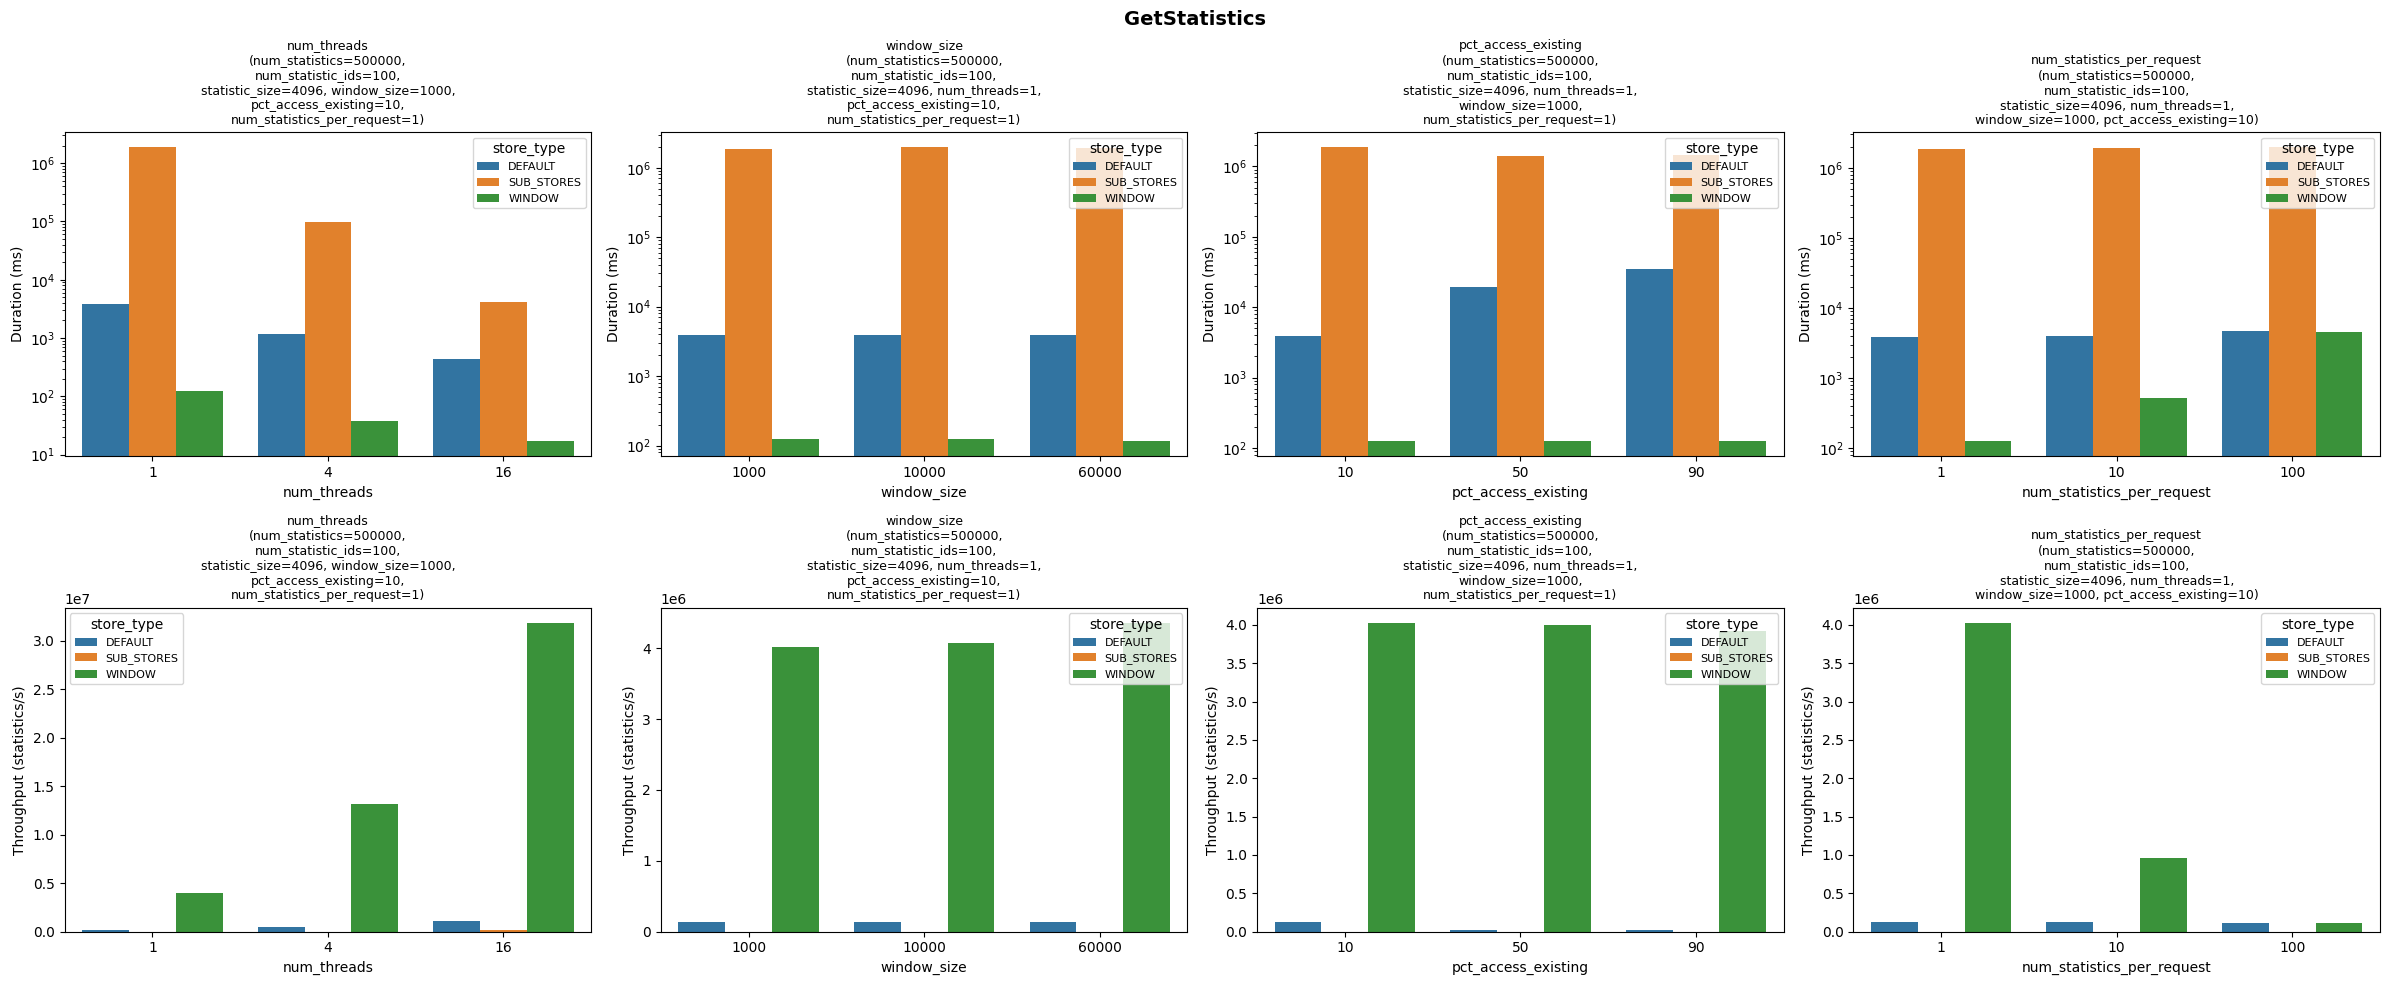

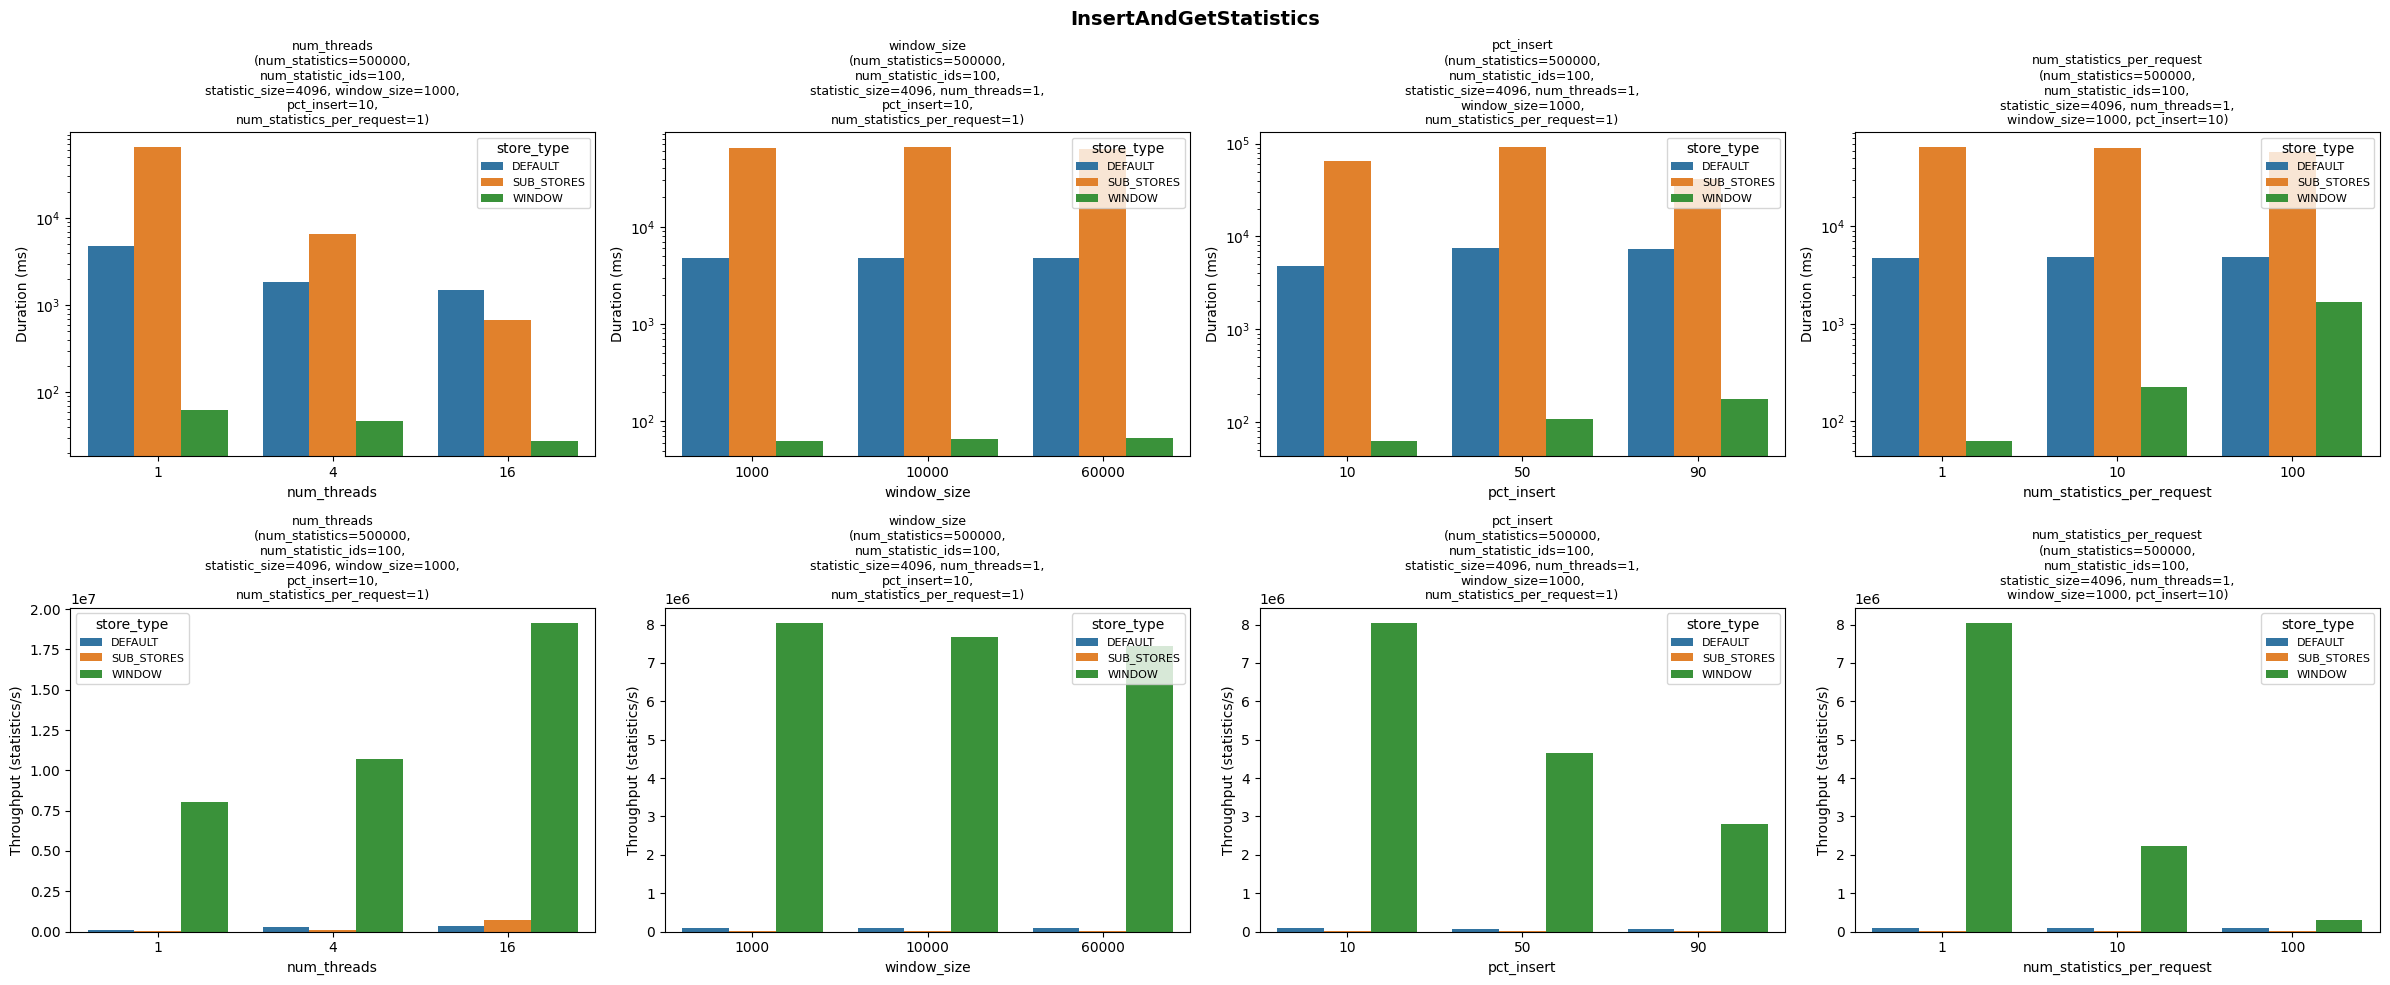

In [9]:
import textwrap

# All other benchmarks (linear y-axis)
for benchmark_name, df_bm in df[df['benchmark'] != 'InsertStatistic'].groupby('benchmark'):
    df_bm = df_bm.copy()

    relevant = [p for p in ALL_PARAMS if not (df_bm[p] == -1).all()]
    varying = [p for p in relevant if df_bm[p].nunique() > 1]
    fixed = [p for p in relevant if p not in varying]

    if not varying:
        print(f"Skipping {benchmark_name}: no varying parameters")
        continue

    group_cols = ['store_type'] + relevant
    df_avg = df_bm.groupby(group_cols, as_index=False)[['duration_ms', 'throughput']].mean()

    n = len(varying)
    fig, axes = plt.subplots(2, n, figsize=(6 * n, 10), squeeze=False)

    for i, param in enumerate(varying):
        other_varying = [v for v in varying if v != param]
        subset = df_avg.copy()
        for ov in other_varying:
            mode_val = subset[ov].mode().iloc[0]
            subset = subset[subset[ov] == mode_val]

        fixed_info = ', '.join(f'{f}={df_bm[f].iloc[0]}' for f in fixed)
        other_info = ', '.join(f'{ov}={subset[ov].iloc[0]}' for ov in other_varying)
        subtitle_parts = [s for s in [fixed_info, other_info] if s]
        if subtitle_parts:
            wrapped = textwrap.fill(', '.join(subtitle_parts), width=40)
            subtitle = f'\n({wrapped})'
        else:
            subtitle = ''

        # Duration
        ax = axes[0][i]
        sns.barplot(data=subset, x=param, y='duration_ms', hue='store_type', ax=ax)
        ax.set_xlabel(param)
        ax.set_yscale('log')
        ax.set_ylabel('Duration (ms)')
        ax.set_title(f'{param}{subtitle}', fontsize=9)
        ax.legend(title='store_type', fontsize=8)

        # Throughput
        ax = axes[1][i]
        sns.barplot(data=subset, x=param, y='throughput', hue='store_type', ax=ax)
        ax.set_xlabel(param)
        ax.set_ylabel('Throughput (statistics/s)')
        ax.set_title(f'{param}{subtitle}', fontsize=9)
        ax.legend(title='store_type', fontsize=8)

    fig.suptitle(benchmark_name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{benchmark_name}.pdf", dpi=300, bbox_inches="tight")
    plt.show()